# Predicting Dissolved Inorganic Carbon (DIC) in California Coastal Waters

**Authors**: Vedika Shirtekar, Melannie Moreno-Rolon, Ixel Medrano

## Background

This notebook documents the modeling workflow used for the EDS 232 final project Kaggle competition. The goal is to predict dissolved inorganic carbon (`DIC`, in µmol/kg) for seawater samples collected by the California Cooperative Oceanic Fisheries Investigations (CalCOFI) program.

The response variable is `DIC`. The predictor variables are:

- `CTDTEMP_ITS90`: sea water temperature in degrees C
- `Salinity_PSS78`: practical salinity
- `Depth`: sample depth below the surface in meters
- `TA`: total alkalinity in µmol/kg

The notebook includes setup, exploratory data analysis, model tuning, model comparison, and creation of Kaggle submission files for predictions generated from random forest and ridge regression models.

## Setup

Load libraries, read the training and test data, and define the response and predictor columns. 

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Set random state to 42 for subsequent model application
RANDOM_STATE = 42 # To set seed

In [124]:
# Split train and test sets
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

In [125]:
# Store the features (predictors) and target
predictors = ["CTDTEMP_ITS90", "Salinity_PSS78", "Depth", "TA"]
response = "DIC"

# Split training for X and y
X = df_train[predictors]
y = df_train[response]

# Split for test set (no y-test set since we will be predicting this value)
X_kaggle_test = df_test[predictors]

## Exploratory Data Analysis

This section checks the structure of the data, missing values, distributions of the predictors and response, and relationships between predictors and `DIC`. These summaries help decide whether nonlinear models may be useful and whether any preprocessing is needed.

In [126]:
# What does each train and test set look like?
print("Training data shape:", df_train.shape)
print("Test data shape:", df_test.shape)

Training data shape: (3389, 6)
Test data shape: (848, 5)


In [127]:
# What does the training set look like?
df_train.head()

,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
0,0,15.36,33.6095,10.0,2241.0,1989.4
1,1,11.23,33.6095,10.0,2241.0,1989.8
2,2,11.23,33.6095,10.0,2241.0,1989.3
3,3,11.23,33.6095,10.0,2241.0,1988.6
4,4,15.06,33.2820,10.0,2241.0,1991.5


In [128]:
# Basic data checks
print("Training columns:")
print(df_train.columns.tolist())

print("\nMissing values in training data:")
print(df_train[predictors + [response]].isna().sum())

print("\nMissing values in test data:")
print(df_test[predictors].isna().sum())

Training columns:
['id', 'CTDTEMP_ITS90', 'Salinity_PSS78', 'Depth', 'TA', 'DIC']

Missing values in training data:
CTDTEMP_ITS90     0
Salinity_PSS78    0
Depth             0
TA                0
DIC               0
dtype: int64

Missing values in test data:
CTDTEMP_ITS90     0
Salinity_PSS78    0
Depth             0
TA                0
dtype: int64


In [129]:
# Summary stats
print("Summary statistics:")
df_train[predictors + [response]].describe()

Summary statistics:


,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
count,3389.000000,3389.000000,3389.000000,3389.000000,3389.000000
mean,11.819258,33.701898,144.232546,2251.047300,2117.764680
std,3.905980,0.375517,262.640488,32.675546,116.876574
min,1.520000,32.700000,0.000000,2163.800000,1934.100000
25%,8.749000,33.415000,10.000000,2229.400000,2008.700000
50%,11.230000,33.609500,50.000000,2241.000000,2083.300000
75%,14.916000,34.068000,230.000000,2267.100000,2225.600000
max,22.750000,34.680000,3542.000000,2462.300000,2364.600000


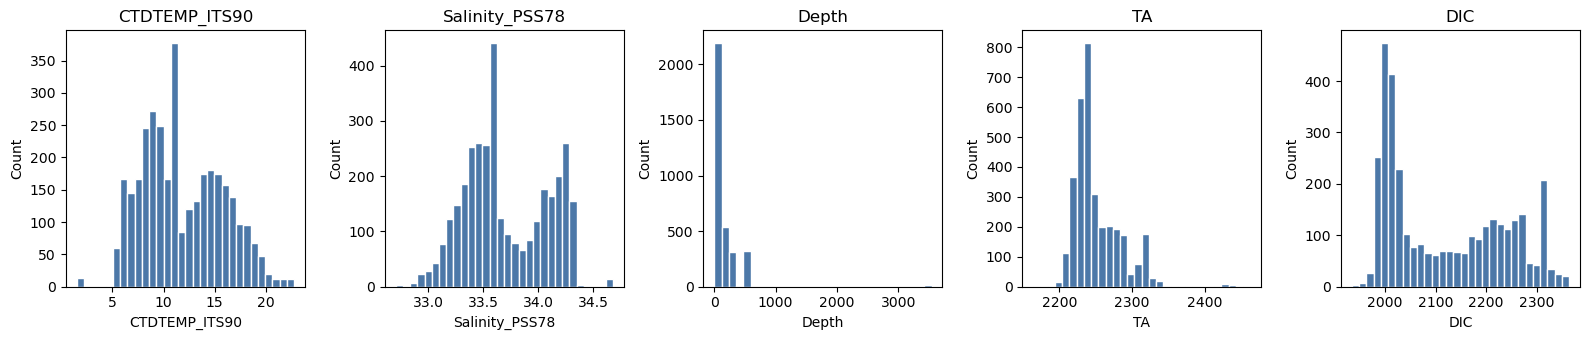

In [130]:
# Distributions of predictors and response
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
cols_to_plot = predictors + [response]

# Plot histogram for each panel
for i in range(len(cols_to_plot)):
    col = cols_to_plot[i]
    ax = axes[i]

    ax.hist(df_train[col], bins=30, color="#4C78A8", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

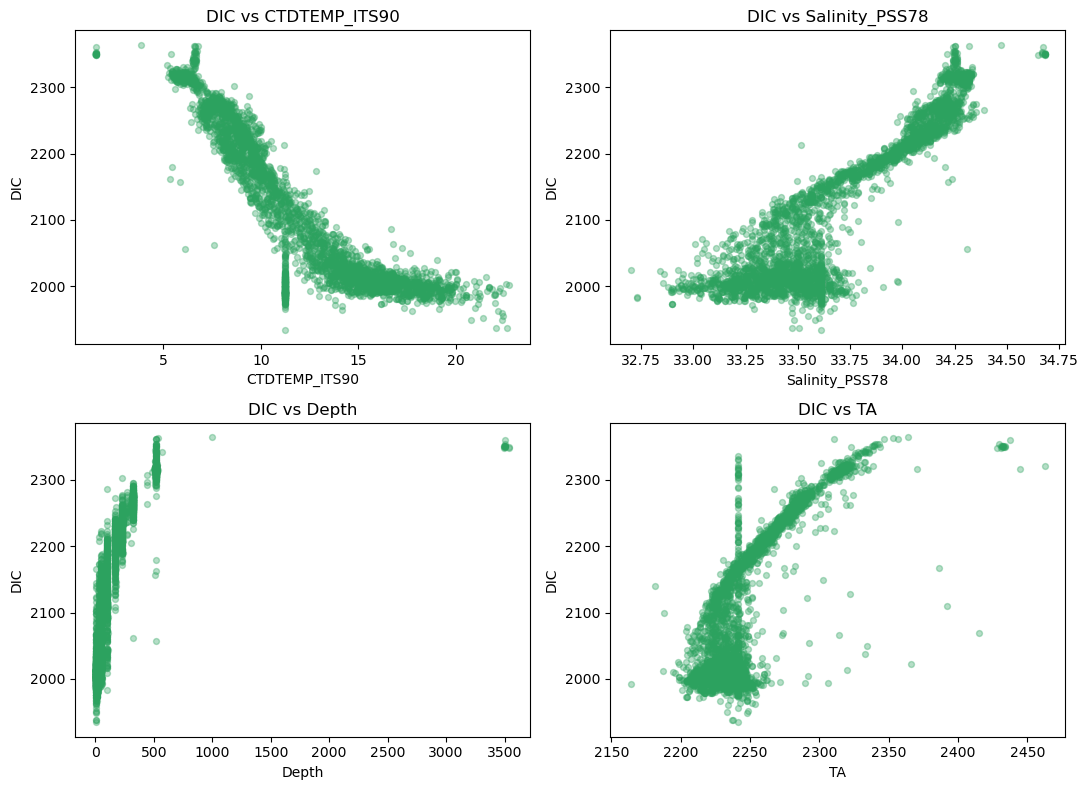

In [131]:
# Relationships between each predictor and DIC
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel() # Flatten multidimensional panel array to 1D

for i in range(len(predictors)):
    col = predictors[i]
    ax = axes[i]

    ax.scatter(df_train[col], df_train[response], alpha=0.35, s=18, color="#2CA25F")
    ax.set_xlabel(col)
    ax.set_ylabel("DIC")
    ax.set_title(f"DIC vs {col}")

plt.tight_layout()
plt.show()

                CTDTEMP_ITS90  Salinity_PSS78     Depth        TA       DIC
CTDTEMP_ITS90        1.000000       -0.778143 -0.606716 -0.673803 -0.880959
Salinity_PSS78      -0.778143        1.000000  0.624730  0.855702  0.898543
Depth               -0.606716        0.624730  1.000000  0.762256  0.643485
TA                  -0.673803        0.855702  0.762256  1.000000  0.803202
DIC                 -0.880959        0.898543  0.643485  0.803202  1.000000


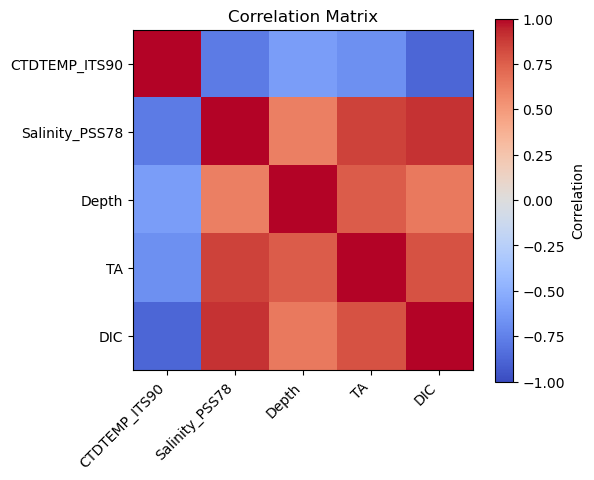

In [132]:
# Correlation matrix for view of linear relationships and influence of features
corr = df_train[predictors + [response]].corr(numeric_only=True)
print(corr)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
plt.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Models

The Kaggle competition evaluates predictions using mean squared error (MSE). In this notebook, models are compared using validation MSE, RMSE, and R². RMSE is included because it is in the same units as `DIC`, which makes interpretation easier.

The workflow consists of the following steps:

1. Split the training data into `X` (features) and `y` (target); this step was done in the preceding section.
2. Fit a multiple linear regression baseline.
3. Tune a ridge regression model using a hyperparameter grid over `alpha`.
4. Tune a random forest regression model using a hyperparameter grid.
5. Compare validation performance and select the best model.
6. Refit the selected model on test data to obtain DIC predictions. 
7. Create submission files to submit to Kaggle and derive a test MSE. 

To ensure our workflow is reproducible, we opted to create a helper function called `evaluate_model` to calculate the three metrics of interest for each model: MSE, RMSE, and R-squared. This function allows are to avoid manually obtaining each metric separately for each model. 

In [133]:
# Create a helper function to evaluate models on the training set
def evaluate_model(model_name, model, X, y):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    return {
        "model": model_name,
        "Train mse": mse,
        "Train rmse": rmse,
        "Train r2": r2
    }

# Store resulting training metrics in empty array
model_results = []

### Model 1: Multiple Linear Regression Baseline

Multiple linear regression is used as a simple baseline. It has no major hyperparameters to tune, so no grid search is needed. This model assumes a linear relationship between the predictors and `DIC`.

In [134]:
# Fit a multiple linear regression baseline
lm = LinearRegression()
lm.fit(X, y)

lm_results = evaluate_model("Multiple Linear Regression",
                            lm,
                            X,
                            y)

model_results.append(lm_results)

# Check model performance on training data
print("Multiple Linear Regression Performance")
print(f"Train MSE:  {lm_results['Train mse']:.4f}")
print(f"Train RMSE: {lm_results['Train rmse']:.4f}")
print(f"Train R²:   {lm_results['Train r2']:.4f}")

# Sort coeficient estimates for each predictor in descending order
pd.Series(lm.coef_, index=predictors).sort_values(ascending=False)

Multiple Linear Regression Performance
Train MSE:  1438.7851
Train RMSE: 37.9313
Train R²:   0.8946


Salinity_PSS78    138.324490
TA                  0.403663
Depth               0.000900
CTDTEMP_ITS90     -13.700393
dtype: float64

### Model 2: Ridge Regression with Hyperparameter Tuning

Ridge regression is a regularized linear model. It keeps the model linear, but adds a penalty that can reduce overfitting when predictors are correlated. The main hyperparameter is `alpha`: larger values apply stronger regularization and shrink coefficients more strongly.

Because ridge regression is sensitive to the scale of the predictors, the training and test features are scaled to prevent some features from dominating.

In [135]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)  # Fit on train only
X_test_scaled   = scaler.transform(X_kaggle_test)  # Reuse train stats

In [136]:
# Now we need to tune with grid search (CV gives comparison MSE)
param_grid = {"alpha": np.logspace(-3, 3, 50)}
ridge_search = GridSearchCV(
    Ridge(), param_grid, scoring="neg_mean_squared_error", cv=5
)
ridge_search.fit(X_train_scaled, y)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
       3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
       9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
       2.94705170e-02, 3.90693994e-02, 5.17947468e-02, 6.86648845e-02,
       9.10298178e-02, 1.20679264e-01, 1.59985872e-01, 2....
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03])},
             scoring='neg_mean_squared_error')

In [137]:
# Extract the best parameters for the model and evaluate
ridge_regression_tuned_results = evaluate_model("Ridge Regression Tuned", ridge_search, X_train_scaled, y)
model_results.append(ridge_regression_tuned_results)

print("Tuned Ridge Regression Performance")
print("Best parameters:", ridge_search.best_params_) # Alpha is lambda tuning parameter
print(f"Train MSE:  {ridge_regression_tuned_results['Train mse']:.4f}")
print(f"Train RMSE: {ridge_regression_tuned_results['Train rmse']:.4f}")
print(f"Train R²:   {ridge_regression_tuned_results['Train r2']:.4f}")

Tuned Ridge Regression Performance
Best parameters: {'alpha': 25.595479226995334}
Train MSE:  1439.1691
Train RMSE: 37.9364
Train R²:   0.8946


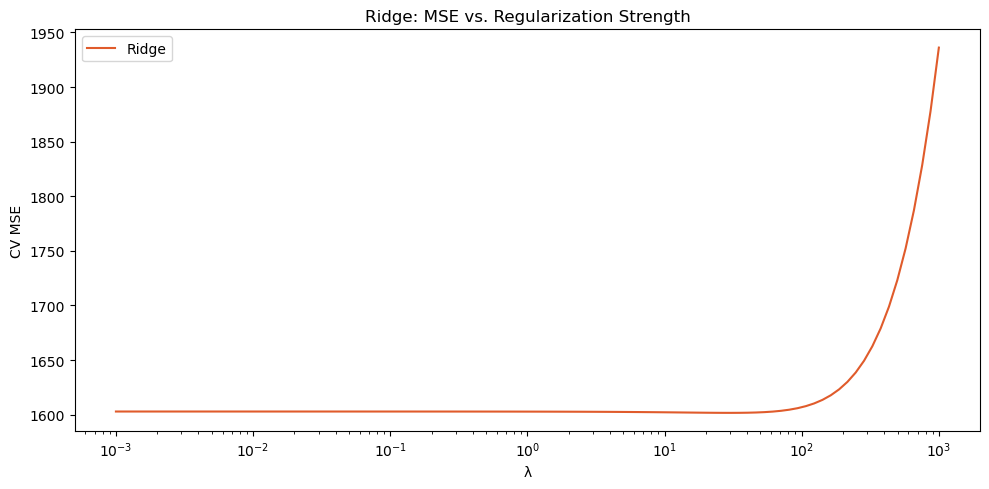

In [138]:
# Visualize the CV MSE for each lambda (taken from lab)
mse_ridge = []
lambdas = np.logspace(-3, 3, 100)
for lam in lambdas:
    scores = cross_val_score(
        Ridge(alpha=lam), X_train_scaled, y,
        scoring="neg_mean_squared_error", cv=5
    )
    mse_ridge.append(-scores.mean())

# Plot
plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_ridge, label='Ridge', color='#E05B2B')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('CV MSE')
plt.title('Ridge: MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()

### Model 3: Random Forest Regression with Hyperparameter Tuning

Random forest regression is a tree-based ensemble method. It builds many decision trees using bootstrapped samples of the training data, then averages their predictions. This makes the model useful for nonlinear relationships and interactions among predictors. Random forest regression is also useful in the event that one or more predictors dominate or heavily influence the response variable since a subset of `m` predictors is randomly sampled from `p` total predictors.


The tuned hyperparameters are:

- `n_estimators`: number of trees in the forest. Essentially, more trees can improve stability but can increase runtime.
- `max_depth`: maximum depth of each tree. Smaller values reduce complexity and can reduce overfitting.
- `min_samples_split`: minimum number of samples required to split an internal node. Larger values make trees less complex.
- `min_samples_leaf`: minimum number of samples required in a terminal leaf. 
- `max_features`: number of predictors considered at each split. 

Random forests do not require feature scaling because they split variables using thresholds.



**Additional information on random forest regression is accessible here: https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/.**


In [139]:
# Baseline random forest before tuning
rf_baseline = RandomForestRegressor(random_state=RANDOM_STATE) # Set seed
rf_baseline.fit(X, y)

rf_baseline_results = evaluate_model("Random Forest Baseline", rf_baseline, X, y)
model_results.append(rf_baseline_results)

print("Baseline Random Forest Performance")
print(f"Train MSE:  {rf_baseline_results['Train mse']:.4f}")
print(f"Train RMSE: {rf_baseline_results['Train rmse']:.4f}")
print(f"Train R²:   {rf_baseline_results['Train r2']:.4f}")

Baseline Random Forest Performance
Train MSE:  33.3764
Train RMSE: 5.7772
Train R²:   0.9976


In [140]:
# Create parameter grid for parameters to tune
rf_param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [8, 10, 12, 15],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 1.0],
} 

# Create parameter grid for RF regression model
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, oob_score=True),
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Fit the RF regression model
rf_grid.fit(X, y)

# Extract the best parameters for the model and evaluate
best_rf = rf_grid.best_estimator_
rf_tuned_results = evaluate_model("Random Forest Tuned", best_rf, X, y)
model_results.append(rf_tuned_results)

print("Tuned Random Forest Performance")
print("Best parameters:", rf_grid.best_params_)
print(f"Train MSE:  {rf_tuned_results['Train mse']:.4f}")
print(f"Train RMSE: {rf_tuned_results['Train rmse']:.4f}")
print(f"Train R²:   {rf_tuned_results['Train r2']:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Tuned Random Forest Performance
Best parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 300}
Train MSE:  60.6596
Train RMSE: 7.7884
Train R²:   0.9956


For a Random Forest, we can also look at the out-of-bag error to see how well the model will generalize on unseen observations. This approach is equivalent to but less computationally expensive to receive with the MSE via CV. 

In [141]:
# Get out-of-bag score for the tuned random forest
print("Out-of-Bag Score:", best_rf.oob_score_)

Out-of-Bag Score: 0.9853761900647353


By checking the feature importance, it is clear that temperature and salinity dominate feature importance, further supporting the option for a random forest.

CTDTEMP_ITS90     0.504236
Salinity_PSS78    0.304770
Depth             0.159282
TA                0.031712
dtype: float64


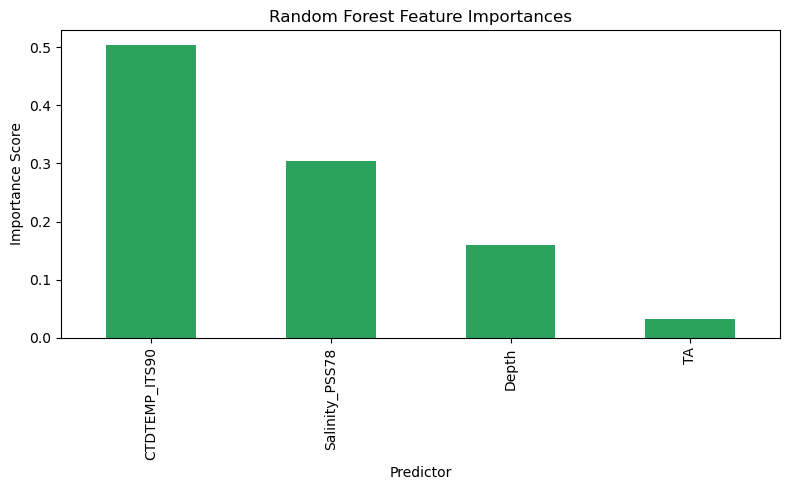

In [142]:
# Feature importance from the tuned random forest
importances = pd.Series(best_rf.feature_importances_, index=predictors).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind="bar", color="#2CA25F")
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance Score")
plt.xlabel("Predictor")
plt.tight_layout()
plt.show()

## Summary

This section compares model performance side by side. Lower values of the train MSE and RMSE, as well as higher values of R-squared, indicate better predictive performance. The final Kaggle submission is created from the selected model after refitting it on all available test data.

In [143]:
# Compare each metric across models in a table
results_df = pd.DataFrame(model_results).sort_values("Train mse")
results_df

,model,Train mse,Train rmse,Train r2
2,Random Forest Baseline,33.376423,5.777233,0.997556
3,Random Forest Tuned,60.659587,7.788426,0.995558
0,Multiple Linear Regression,1438.785117,37.931321,0.894642
1,Ridge Regression Tuned,1439.169096,37.936382,0.894613


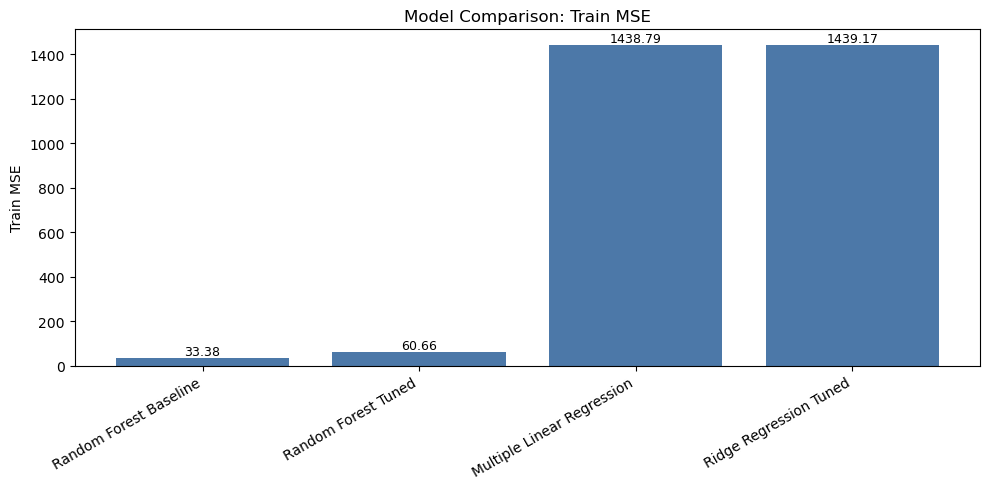

In [144]:
# Plot validation MSE for model comparison
plot_df = results_df.sort_values("Train mse", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.bar(plot_df["model"], plot_df["Train mse"], color="#4C78A8")
plt.ylabel("Train MSE")
plt.title("Model Comparison: Train MSE")
plt.xticks(rotation=30, ha="right")

for i in range(len(bars)):
    bar = bars[i]
    rmse = plot_df["Train mse"].iloc[i]

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rmse:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

Based on the tuned performances of each model, the tuned random forest is selected as the final model. The linear models are useful baselines, however, the random forest is likely to perform better because the relationship between DIC and the oceanographic predictors is nonlinear. Random forests can capture threshold effects and interactions among temperature, salinity, depth, and total alkalinity without requiring manually created polynomial or interaction terms.

The feature importance results from the tuned random forest also help interpret the model. In this validation workflow, temperature, salinity, and depth were the strongest predictors. TA had lower random forest importance; however, this should not be interpreted as meaning TA is not scientifically relevant.

## Final Kaggle Submission

The selected random forest model is refit using all rows in `train.csv`, then predictions are generated for every row in `test.csv`. The submission files unique to each model contains exactly two columns: `id` and `DIC`.

In [ ]:
# Fit final models 
final_rf = RandomForestRegressor(
    **rf_grid.best_params_, # Use best params from grid search
    random_state=RANDOM_STATE
)
final_rf.fit(X, y)

# Generate predictions on the Kaggle test set
# Please note the the tree models use unscaled X while ridge uses the scaled X
tuned_rf_preds    = final_rf.predict(X_kaggle_test) # Tuned Rf
baseline_rf_preds = rf_baseline.predict(X_kaggle_test) # Untuned Rf 
ridge_preds       = ridge_search.predict(X_test_scaled) # SCALED X for ridge

# Build submission data frames
submissions = {
    "data-submission/submission_random_forest_tuned.csv": tuned_rf_preds,
    "data-submission/submission_random_forest_baseline.csv": baseline_rf_preds,
    "data-submission/submission_ridge.csv": ridge_preds,
}

# Write each submission to directory (this approach is good for telling a reader which submission is which and for keeping track of multiple submissions)
for path, preds in submissions.items():
    pd.DataFrame({"id": df_test["id"], "DIC": preds}).to_csv(path, index=False)
    print(f"Saved submission to: {path}")

Saved submission to: data-submission/submission_random_forest_tuned.csv
Saved submission to: data-submission/submission_random_forest_baseline.csv
Saved submission to: data-submission/submission_ridge.csv


## Final Notes
The final selected model is the tuned random forest regression model because it had the "strongest" performance among the tuned random forest and ridge regression models. The model was then used to generate test set predictions, which allows the final model to learn from all available labeled observations. The test MSE was evaluated on the submission dataset for both models. 